<a href="https://colab.research.google.com/github/paulinaniemczak/Machine-Learning/blob/master/HW_Lab10-convolutional-neural-network-CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 10 - Convolutional Neural Network, CNN

### Author: Szymon Nowakowski


# Presentation on Convolutional Layers
--------------------

We shall start off by going through a [short presentation on convolusional layers](https://github.com/SzymonNowakowski/Machine-Learning-2025/blob/master/convolutional_layers.pdf). It is best to first download it and then go through it in a slide-show layout.

# Reading MNIST Dataset
----------------------------------

In [ ]:
import torch
import torchvision
from matplotlib import pyplot

transform = torchvision.transforms.Compose(
    [ torchvision.transforms.ToTensor(), #Converts a PIL Image or numpy.ndarray (H x W x C) in the range [0, 255] to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0]
      torchvision.transforms.Normalize((0.1307), (0.3081))])

trainset = torchvision.datasets.MNIST(root='./data',
                                      train=True,
                                      download=True,
                                      transform=transform)

trainloader = torch.utils.data.DataLoader(trainset,
                                          batch_size=2048,
                                          shuffle=True)   #we do shuffle it to give more randomizations to training epochs

testset = torchvision.datasets.MNIST(root='./data',
                                     train=False,
                                     download=True,
                                     transform=transform)

testloader = torch.utils.data.DataLoader(testset,
                                         batch_size=1,
                                         shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.45MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 126kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.5MB/s]


# Tensor Sizes
-------------------

Recall:
- Batched labels are of order one. The first (and only) index is a sample index within a batch.
- Image batches have order 4. The first order is a batch order, but a second order has dimensionality of 1 and thus it can be indexed by 0 only.
  - This index represents a Channel number inserted here by `ToTensor()` transformation, always 0.
  - This singleton order should be retained because we want to use convolutional layers, which explicitly require this order. For RGB images we have 3 channels, for B&W images we have only one channel.


# CNN Definition
-----------------



## Task

Your job now is to code the definition of the LeNet5 neural network. You can find the definition [here](https://en.wikipedia.org/wiki/LeNet#/media/File:Comparison_image_neural_networks.svg).


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(torch.nn.Module):
    def __init__(self):
        super().__init__()

        # TODO: add missing layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)

        # 16x4x4 for our data
        self.fc1 = nn.Linear(in_features=16*5*5, out_features=120)
        self.fc2 = nn.Linear(in_features=120, out_features=84)
        self.fc3 = nn.Linear(in_features=84, out_features=10)


        self.dropout = torch.nn.Dropout(0.05)


    def forward(self, x):
        # print("input:", x.shape)
        # TODO: add missing processing

        # convolution with sigmoid
        x = torch.sigmoid(self.conv1(x))
        # print("conv1:", x.shape)

        # pooling
        x = F.avg_pool2d(x, kernel_size=2, stride=2)
        # print("pool1:", x.shape)

        # convolution with sigmoid 2
        x = torch.sigmoid(self.conv2(x))
        # print("conv2:", x.shape)

        # pooling
        x = F.avg_pool2d(x, kernel_size=2, stride=2)
        # print("pool2:", x.shape)

        # flatten
        x = torch.flatten(x, start_dim=1)
        # print("flatten:", x.shape)

        # linear
        x = torch.sigmoid(self.fc1(x))
        # print("fc1:", x.shape)

        # linear
        x = torch.sigmoid(self.fc2(x))

        # last
        x = self.fc3(x)

        # convolution
        x = self.dropout(x)
        return x

# Training Loop
----------------------

In [ ]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on {device}")

net = LeNet5().to(device)
optimizer = torch.optim.Adam(net.parameters(), 0.001)   #initial and fixed learning rate of 0.001.

net.train()    #it notifies the network layers (especially batchnorm or dropout layers, which we don't use in this example) that we are doing traning
for epoch in range(16):  #  an epoch is a training run through the whole data set

    for batch, data in enumerate(trainloader):
        batch_inputs, batch_labels = data

        batch_inputs = batch_inputs.to(device)  #explicitly moving the data to the target device
        batch_labels = batch_labels.to(device)

        # print(batch_inputs.shape)
        # print(batch_labels.shape)

        optimizer.zero_grad()

        batch_outputs = net(batch_inputs)   #this line calls the forward(self, x) method of the LeNet5 object. Please note,
                                            # the nonlinear activation after the last layer is NOT applied
        loss = torch.nn.functional.cross_entropy(batch_outputs, batch_labels, reduction = "mean") #instead, nonlinear softmax is applied internally in THIS loss function
        print("epoch:", epoch, "batch:", batch, "current batch loss:", loss.item())
        loss.backward()       #this computes gradients as we have seen in previous workshops
        optimizer.step()     #but this line in fact updates our neural network.
                                ####You can experiment - comment this line and check, that the loss DOE

Working on cuda
epoch: 0 batch: 0 current batch loss: 2.3242838382720947
epoch: 0 batch: 1 current batch loss: 2.319371223449707
epoch: 0 batch: 2 current batch loss: 2.3021926879882812
epoch: 0 batch: 3 current batch loss: 2.3032655715942383
epoch: 0 batch: 4 current batch loss: 2.304508924484253
epoch: 0 batch: 5 current batch loss: 2.3015995025634766
epoch: 0 batch: 6 current batch loss: 2.304919719696045
epoch: 0 batch: 7 current batch loss: 2.304497241973877
epoch: 0 batch: 8 current batch loss: 2.3079447746276855
epoch: 0 batch: 9 current batch loss: 2.3086676597595215
epoch: 0 batch: 10 current batch loss: 2.305727481842041
epoch: 0 batch: 11 current batch loss: 2.303750991821289
epoch: 0 batch: 12 current batch loss: 2.303466558456421
epoch: 0 batch: 13 current batch loss: 2.306675434112549
epoch: 0 batch: 14 current batch loss: 2.2988288402557373
epoch: 0 batch: 15 current batch loss: 2.301816940307617
epoch: 0 batch: 16 current batch loss: 2.3007097244262695
epoch: 0 batch: 1

# Testing
----------------------

In [ ]:
good = 0
wrong = 0

net.eval()              #it notifies the network layers (especially batchnorm or dropout layers, which we don't use in this example) that we are doing evaluation
with torch.no_grad():   #it prevents that the net learns during evalution. The gradients are not computed, so this makes it faster, too
    for batch, data in enumerate(testloader): #batches in test are of size 1
        datapoint, label = data

        prediction = net(datapoint.to(device))                  #prediction has values representing the "prevalence" of the corresponding class
        classification = torch.argmax(prediction)    #the class is the index of maximal "prevalence"

        if classification.item() == label.item():
            good += 1
        else:
            wrong += 1

print("accuracy = ", good/(good+wrong))

accuracy =  0.9344


# Understanding Kernel Size, Stride and Padding

## Task: Designing a Convolutional Neural Network with a Target Receptive Field

Design a convolutional neural network using only 3×3 or 5×5 convolutional layers and 2×2 max-pooling layers without overlap (i.e., with stride 2). Use no padding in any layer. Insert a max-pooling layer after every two or three convolutional layers.

Your goal is to construct an architecture such that the receptive field of each output neuron is approximately 60×60 pixels.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# input size is 400x400

class field_net(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3)
    self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
    self.conv3 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3)
    self.conv4 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5)
    self.conv5 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=5)
    self.conv6 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3)
    self.conv7 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3)


    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

  def forward(self, x):
    x = self.conv1(x)
    x = F.relu(x)
    x = self.conv2(x)
    x = F.relu(x)

    x = self.pool(x)

    x = self.conv3(x)
    x = F.relu(x)
    x = self.conv4(x)
    x = F.relu(x)

    x = self.pool(x)
    x = self.conv5(x)
    x = F.relu(x)
    x = self.conv6(x)
    x = F.relu(x)

    x = self.pool(x)
    x = self.conv7(x)

    return x

**Answers**

Compute the receptive field size of the final output layer.
**66**

Compute the effective stride of the output layer with respect to the input.
**8**

Assuming an input image size of 400×400, determine the spatial size of the output feature map.
**42x42x512**

Q: Where would you locate ReLU layers?
**After every convolutional layer, so the nonlinearity is introduced and the learning is improved.**

Q: What if we can't match the desired input size with our architecture?
**The architecture can be slightly modified by adding or removing convolutional layer or changing the kernel size.**

Q: Discuss what possible impact padding can have on the network performance.
**Padding preserves spatial size of output feature map and prevents border information loss, but also adds artificial information that may slightly affect feature extraction.**

# **Homework Assignment – Adversarial Examples**

In this assignment, you will explore how small (invisible to humans) changes to real digits can _fool_ the CNN into misclassifying them, even though the changes are imperceptible to humans.



## Task 1 – CNN Dreams: Last Homework Assignment Revisited

Re-run the input optimization process (for NN dreams) from the previous MLP-class homework assignment, but this time using the **LeNet-5 CNN model** we trained in this class.


1. Starting from ten random noise images, optimize the input so that each image is classified with high confidence as one of the digits 0 through 9.
2. Include an **L2 penalty** on the input to keep the images visually closer to realistic digits. Use a range of penalty strengths (e.g., $\lambda_{l2}$ = 0, and then 0.01 through 10.0).
3. Compare the generated images (with and without L2 penalty) to those generated by the MLP:
   - Are they more or less readable?
   - Do they resemble real MNIST digits more closely or less?
   - Why do you think that happens? Consider the CNN’s inductive biases and architectural properties.

Use `cross_entropy_loss + lambda_l2 * input.pow(2).mean()` as your objective.

Reuse your code: visualize confidence evolution during optimization and generate image grids and (optionally) animations showing how the inputs evolve.




iteration: 0 loss: 3.670938014984131 mean confidence: 0.16104164719581604
iteration: 25 loss: 0.019016031175851822 mean confidence: 0.9811792373657227
iteration: 50 loss: 0.01618550531566143 mean confidence: 0.983954131603241
iteration: 75 loss: 0.015224416740238667 mean confidence: 0.9849002957344055
iteration: 100 loss: 0.014740748330950737 mean confidence: 0.9853765368461609
iteration: 125 loss: 0.014432278461754322 mean confidence: 0.9856804013252258
iteration: 150 loss: 0.014212330803275108 mean confidence: 0.9858971834182739
iteration: 175 loss: 0.014043156988918781 mean confidence: 0.9860638976097107
iteration: 200 loss: 0.01390541810542345 mean confidence: 0.9861995577812195
iteration: 225 loss: 0.013788449577987194 mean confidence: 0.9863149523735046
iteration: 250 loss: 0.013685855083167553 mean confidence: 0.9864160418510437
iteration: 275 loss: 0.013593917712569237 mean confidence: 0.9865066409111023


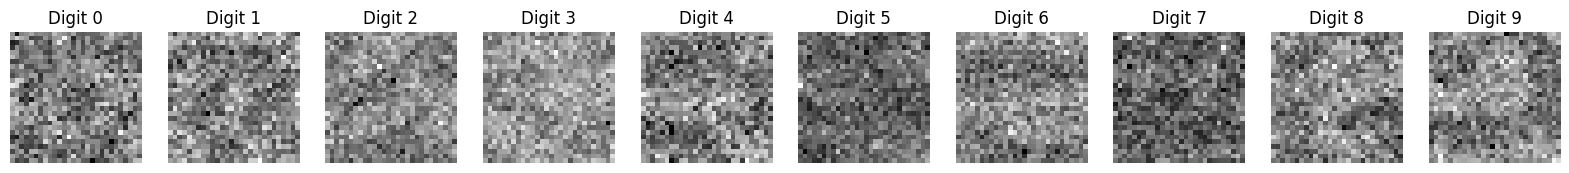

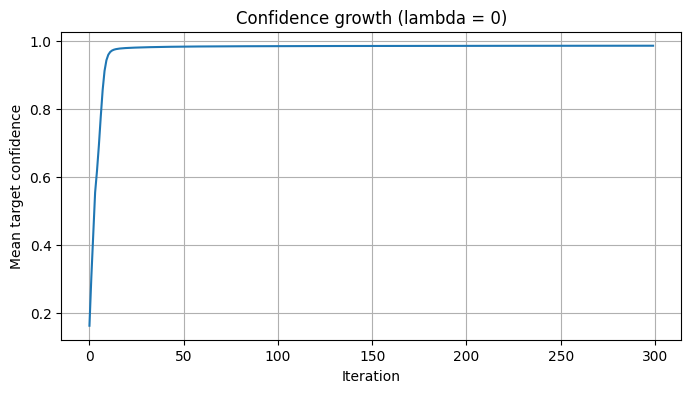

iteration: 0 loss: 4.166104316711426 mean confidence: 0.08908679336309433
iteration: 25 loss: 0.030409978702664375 mean confidence: 0.9813593029975891
iteration: 50 loss: 0.02841855026781559 mean confidence: 0.9834374785423279
iteration: 75 loss: 0.02726186066865921 mean confidence: 0.9843096137046814
iteration: 100 loss: 0.02638675644993782 mean confidence: 0.9848548769950867
iteration: 125 loss: 0.025662478059530258 mean confidence: 0.9852455258369446
iteration: 150 loss: 0.025032665580511093 mean confidence: 0.9855460524559021
iteration: 175 loss: 0.024470292031764984 mean confidence: 0.9857865571975708
iteration: 200 loss: 0.023958543315529823 mean confidence: 0.9859849214553833
iteration: 225 loss: 0.02348552830517292 mean confidence: 0.9861534237861633
iteration: 250 loss: 0.023043189197778702 mean confidence: 0.9863002896308899
iteration: 275 loss: 0.02262759953737259 mean confidence: 0.9864296317100525


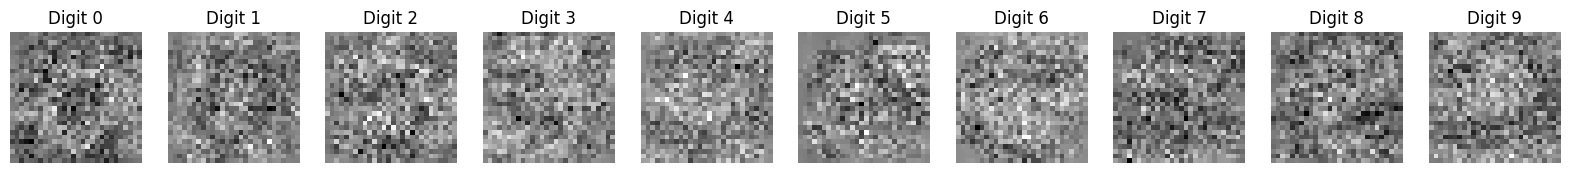

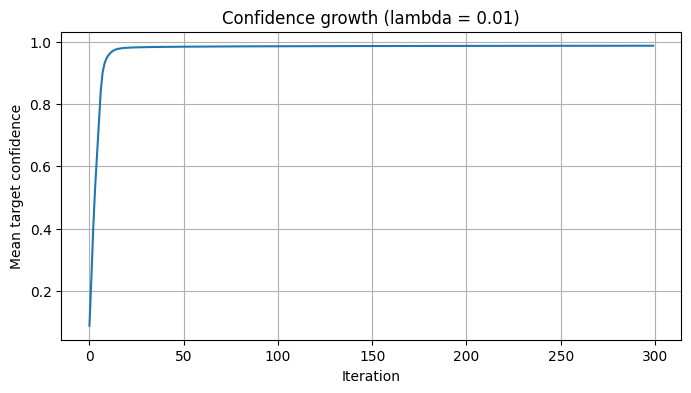

iteration: 0 loss: 4.303924083709717 mean confidence: 0.1412232518196106
iteration: 25 loss: 0.12661106884479523 mean confidence: 0.9791024327278137
iteration: 50 loss: 0.11115245521068573 mean confidence: 0.9824203848838806
iteration: 75 loss: 0.09706289321184158 mean confidence: 0.9833855032920837
iteration: 100 loss: 0.08545508235692978 mean confidence: 0.9839710593223572
iteration: 125 loss: 0.07589675486087799 mean confidence: 0.9844034314155579
iteration: 150 loss: 0.06793124228715897 mean confidence: 0.9847504496574402
iteration: 175 loss: 0.06122799590229988 mean confidence: 0.9850395321846008
iteration: 200 loss: 0.05554337427020073 mean confidence: 0.9852814078330994
iteration: 225 loss: 0.050690509378910065 mean confidence: 0.9854828119277954
iteration: 250 loss: 0.046524778008461 mean confidence: 0.9856491088867188
iteration: 275 loss: 0.04293467104434967 mean confidence: 0.9857829213142395


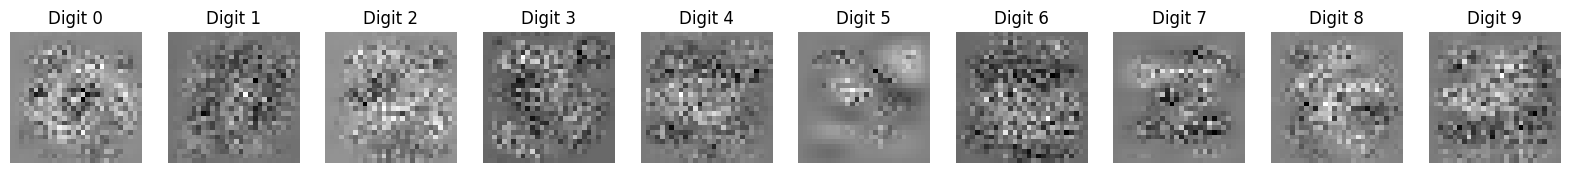

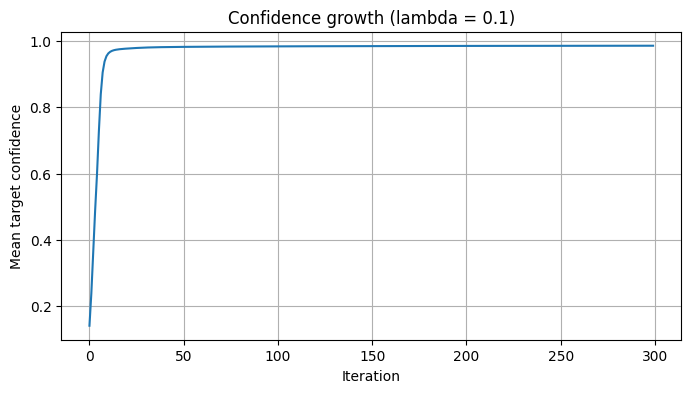

iteration: 0 loss: 5.48069429397583 mean confidence: 0.09293173998594284
iteration: 25 loss: 0.7119415402412415 mean confidence: 0.9793550372123718
iteration: 50 loss: 0.4074706435203552 mean confidence: 0.9823171496391296
iteration: 75 loss: 0.24262675642967224 mean confidence: 0.9827455878257751
iteration: 100 loss: 0.1548120677471161 mean confidence: 0.9823527336120605
iteration: 125 loss: 0.10618403553962708 mean confidence: 0.9817463159561157
iteration: 150 loss: 0.07815290242433548 mean confidence: 0.9813067317008972
iteration: 175 loss: 0.06139302998781204 mean confidence: 0.9810346961021423
iteration: 200 loss: 0.05108458548784256 mean confidence: 0.9808887839317322
iteration: 225 loss: 0.044604361057281494 mean confidence: 0.9808252453804016
iteration: 250 loss: 0.04046357795596123 mean confidence: 0.9807937741279602
iteration: 275 loss: 0.03778518736362457 mean confidence: 0.9807766079902649


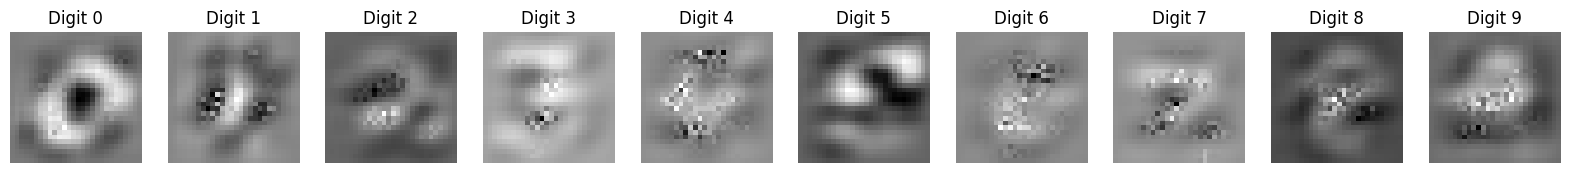

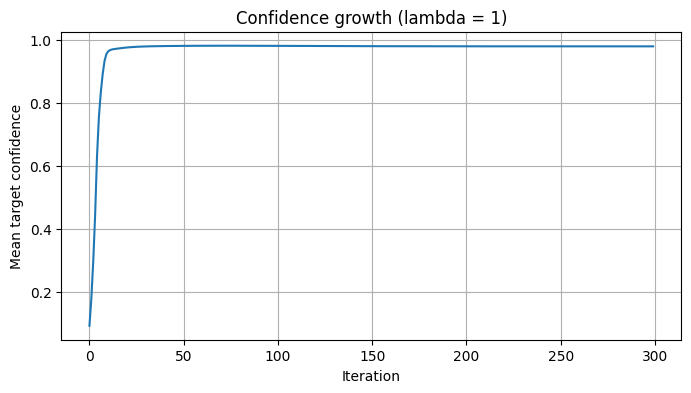

iteration: 0 loss: 14.174043655395508 mean confidence: 0.09328850358724594
iteration: 25 loss: 2.1432414054870605 mean confidence: 0.9654925465583801
iteration: 50 loss: 0.36308032274246216 mean confidence: 0.9534085392951965
iteration: 75 loss: 0.1386125534772873 mean confidence: 0.9583584666252136
iteration: 100 loss: 0.1116744875907898 mean confidence: 0.9588910937309265
iteration: 125 loss: 0.10843969881534576 mean confidence: 0.958976686000824
iteration: 150 loss: 0.1080213338136673 mean confidence: 0.9589719176292419
iteration: 175 loss: 0.10796317458152771 mean confidence: 0.9589653015136719
iteration: 200 loss: 0.10795525461435318 mean confidence: 0.9589670300483704
iteration: 225 loss: 0.10795430839061737 mean confidence: 0.9589682817459106
iteration: 250 loss: 0.1079542264342308 mean confidence: 0.9589683413505554
iteration: 275 loss: 0.10795419663190842 mean confidence: 0.958968460559845


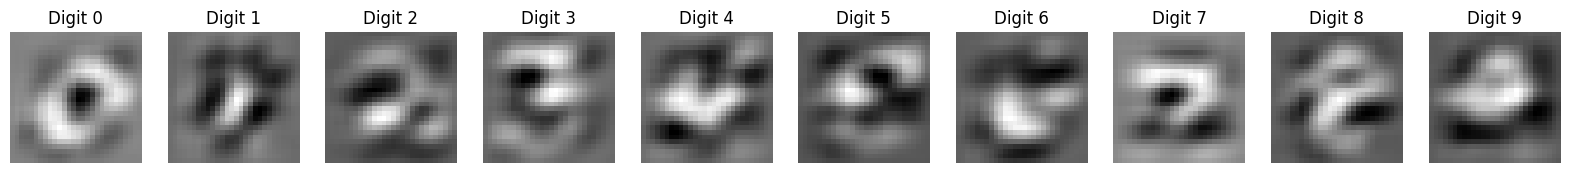

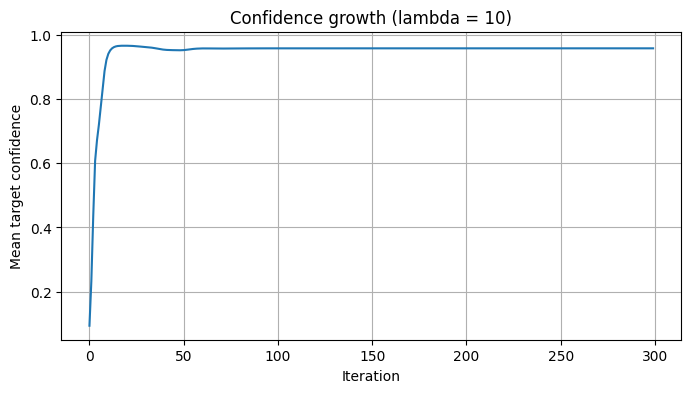

In [ ]:
"""enhanced code from previous lab"""
net.eval() # LeNet-5 without training behaviors

for param in net.parameters():
  param.requires_grad = False # without weights' training

target_labels = torch.arange(10).to(device) # target labels for images from 0 to 9, tensor shape: 10


lambda_values = [0, 0.01, 0.1, 1, 10]
for lambda_l2 in lambda_values:
  dream_batch_input = torch.randn(10, 1, 28, 28, device=device) # batch of random noise images, shape: batch size, channels (grayscale, so 1), height, width
  dream_batch_input.requires_grad_(True) # gradient for input images
  dream_optimizer = torch.optim.Adam([dream_batch_input], lr=0.05) # updates input images

  iterations = 300
  confidence_history = []

  for iteration in range(iterations):
    dream_optimizer.zero_grad() # reset gradient from previous iteration

    outputs = net(dream_batch_input) # pass images

    ce_loss = F.cross_entropy(outputs, target_labels) # cross-entropy loss, digit named by their digit
    l2 = dream_batch_input.pow(2).mean()
    loss = ce_loss + lambda_l2 * l2 # total loss

    loss.backward() # gradients
    dream_optimizer.step() # update images using gradients

    probabilities = torch.softmax(outputs, dim=1)
    target_confidence = probabilities[torch.arange(10), target_labels] # confidence of given class

    confidence_history.append(target_confidence.mean().item()) # save confidence for later visualisation


    if iteration % 25 == 0:
      print(
          "iteration:", iteration,
          "loss:", loss.item(),
          "mean confidence:", target_confidence.mean().item()
      )


  # plotting
  images = dream_batch_input.detach().cpu() # moves tensor to cpu

  figure, axes = pyplot.subplots(1, 10, figsize=(20, 2))
  for i in range(10):
    image = images[i][0]
    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(f"Digit {i}")
    axes[i].axis("off")
  pyplot.show()


  """ confidence growth during optimization """
  pyplot.figure(figsize=(8, 4))
  pyplot.plot(confidence_history)
  pyplot.title(f"Confidence growth (lambda = {lambda_l2})")
  pyplot.xlabel("Iteration")
  pyplot.ylabel("Mean target confidence")
  pyplot.grid()
  pyplot.show()


These results seem to be better than those obtained with previous MLP network. Especially with the highest lambda value, the images resemble MNIST numbers in more visible way.

As the lambda value increases:
- the confidence decreases (due to stronger penalization of changes made to original image)
- loss value increases (because of larger contribution of regularization)
- values get more human eye readable (optimization is forced to produce less noisy images)

LeNet-5 gives better images because of convolutional architecture that saves spatial information, learns characteristic elements of numbers and has less probability of generating random shapes.

## Task 2 – Adversarial Examples: Fooling LeNet-5

This is the core focus of the assignment.

Using a batch of **real MNIST digits** (e.g., nine examples per class), craft **adversarial examples** by adding subtle, trained noise to the input images. Your goal is to:

- **Keep the human-perceived digit the same** (e.g., a "7" should still look like a "7"),
- But **cause LeNet-5 to misclassify it** – as every other class different from the original, hence nine examples per class.

### Objective
For each image $x$ and its true label $y$, learn a perturbation $\delta$ such that:

- $\text{LeNet5}(x + \delta) = y_{\text{wrong}} $,
- and $ \|\delta\|_2 $ is as small as possible (penalize large perturbations), to keep $x + \delta$ *look* like $x$ for humans.

### Optimization
Use gradient-based optimization on $\delta$ (the noise), while keeping the network weights frozen. Your loss might look like:

```
loss = cross_entropy(model(x + delta), target_wrong_class) +
       lambda_l2 * delta.pow(2).mean()
```

Tune the $\lambda_{l2}$ to find the best range.

### Deliverables for the Second Task
- Select some best examples, showing the original digit and its (correct) classification and the perturbed digit (hopefully, still looking the same to humans) and how it gets misclassified. Show them side by side.
- Report:
  - Success rate of attacks (it doesn't need to be very formal),
  - Effect of $\lambda_{l2}$ on visibility of the noise and success of misclassification,
  - Example image grids and confidence plots.



## Deliverables for the Homework Assignment
- A Google Colab notebook with:
  - Complete implementation for both tasks.
  - Visualizations and animations (animations are optional but encouraged).
  - Clear written analysis of your findings.
- Upload the notebook and results to your GitHub repository for the course.
- Include a link to the notebook and video (if applicable) in the `README.md`.
- In the notebook, include “Open in Colab” badge so it can be launched directly.

image.shape: torch.Size([1, 28, 28])
label: 7
image.shape: torch.Size([1, 1, 28, 28])
lambda= 0
delta.shape: torch.Size([1, 1, 28, 28])
iteration: 0 loss: 6.359677314758301 mean confidence: 0.0017299249302595854
iteration: 25 loss: 0.3641801178455353 mean confidence: 0.6947660446166992
iteration: 50 loss: 0.018114840611815453 mean confidence: 0.9820482730865479
iteration: 75 loss: 0.014180961064994335 mean confidence: 0.9859191179275513
iteration: 100 loss: 0.011522294022142887 mean confidence: 0.9885438084602356
iteration: 125 loss: 0.010088169947266579 mean confidence: 0.9899625182151794
iteration: 150 loss: 0.009146102704107761 mean confidence: 0.9908955693244934
iteration: 175 loss: 0.008446800522506237 mean confidence: 0.9915887713432312
iteration: 200 loss: 0.007896988652646542 mean confidence: 0.9921340942382812
iteration: 225 loss: 0.007451123557984829 mean confidence: 0.992576539516449
iteration: 250 loss: 0.007082357071340084 mean confidence: 0.9929426908493042
iteration: 275

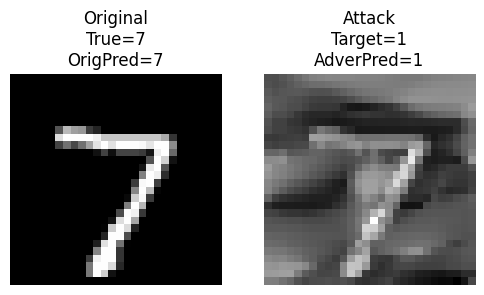

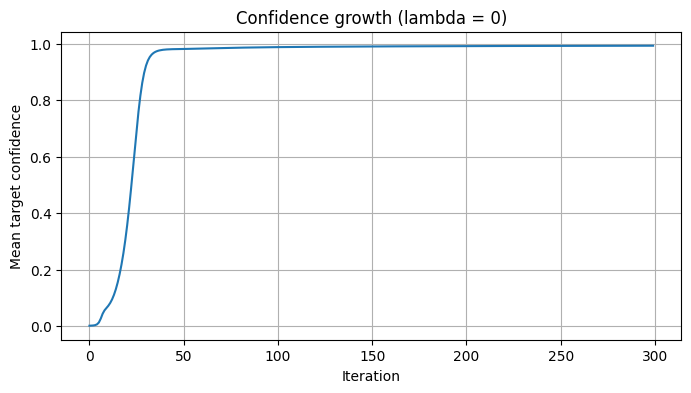

tensor([1], device='cuda:0')
torch.Size([1, 10])
lambda= 0.01
delta.shape: torch.Size([1, 1, 28, 28])
iteration: 0 loss: 6.359677314758301 mean confidence: 0.0017299249302595854
iteration: 25 loss: 0.3689202070236206 mean confidence: 0.6953061819076538
iteration: 50 loss: 0.027853086590766907 mean confidence: 0.9821391701698303
iteration: 75 loss: 0.024132564663887024 mean confidence: 0.9860706925392151
iteration: 100 loss: 0.02121046558022499 mean confidence: 0.98867267370224
iteration: 125 loss: 0.0195205919444561 mean confidence: 0.9900484085083008
iteration: 150 loss: 0.01834796369075775 mean confidence: 0.9909380674362183
iteration: 175 loss: 0.017436090856790543 mean confidence: 0.9915907382965088
iteration: 200 loss: 0.016686705872416496 mean confidence: 0.9920989274978638
iteration: 225 loss: 0.016052404418587685 mean confidence: 0.9925060868263245
iteration: 250 loss: 0.01550423912703991 mean confidence: 0.9928386807441711
iteration: 275 loss: 0.015022482722997665 mean confide

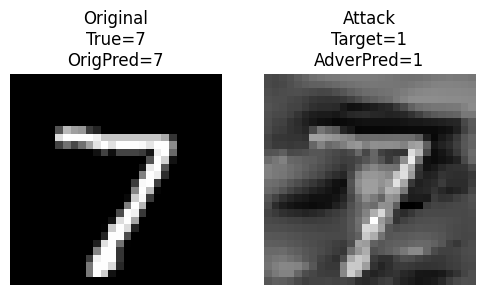

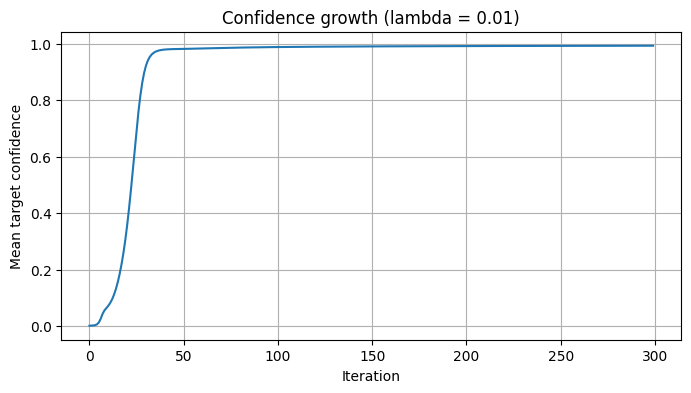

tensor([1], device='cuda:0')
torch.Size([1, 10])
lambda= 0.1
delta.shape: torch.Size([1, 1, 28, 28])
iteration: 0 loss: 6.359677314758301 mean confidence: 0.0017299249302595854
iteration: 25 loss: 0.41030392050743103 mean confidence: 0.7002065181732178
iteration: 50 loss: 0.10548389703035355 mean confidence: 0.982909083366394
iteration: 75 loss: 0.0924796462059021 mean confidence: 0.9872019290924072
iteration: 100 loss: 0.07854647934436798 mean confidence: 0.9891976714134216
iteration: 125 loss: 0.06835200637578964 mean confidence: 0.9897061586380005
iteration: 150 loss: 0.060682106763124466 mean confidence: 0.9899033308029175
iteration: 175 loss: 0.05471424758434296 mean confidence: 0.9901298880577087
iteration: 200 loss: 0.050023142248392105 mean confidence: 0.9903226494789124
iteration: 225 loss: 0.04632245749235153 mean confidence: 0.9904289245605469
iteration: 250 loss: 0.04339496046304703 mean confidence: 0.9904745221138
iteration: 275 loss: 0.04107939451932907 mean confidence: 0

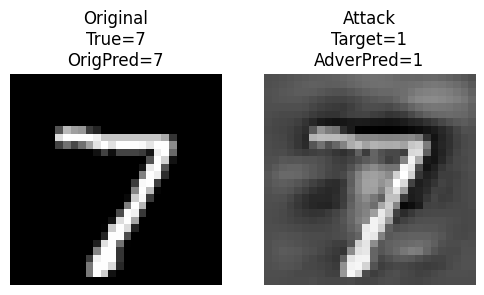

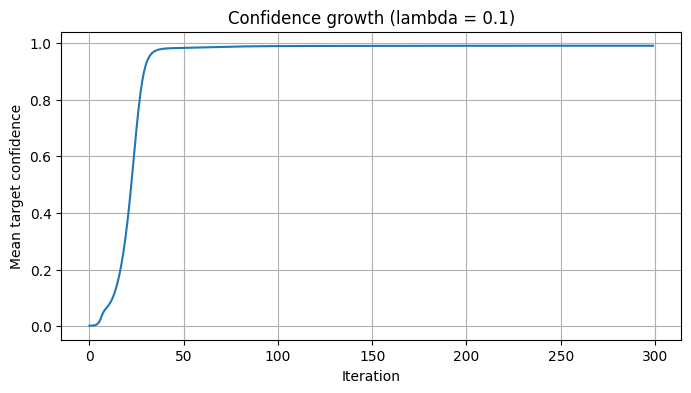

tensor([1], device='cuda:0')
torch.Size([1, 10])
lambda= 1
delta.shape: torch.Size([1, 1, 28, 28])
iteration: 0 loss: 6.359677314758301 mean confidence: 0.0017299249302595854
iteration: 25 loss: 0.7522151470184326 mean confidence: 0.7375819087028503
iteration: 50 loss: 0.4477244019508362 mean confidence: 0.9849417209625244
iteration: 75 loss: 0.2763212025165558 mean confidence: 0.9623411893844604
iteration: 100 loss: 0.22905458509922028 mean confidence: 0.9652681946754456
iteration: 125 loss: 0.21768245100975037 mean confidence: 0.9681202173233032
iteration: 150 loss: 0.21440249681472778 mean confidence: 0.9693770408630371
iteration: 175 loss: 0.213151752948761 mean confidence: 0.9700284600257874
iteration: 200 loss: 0.21262836456298828 mean confidence: 0.9703428149223328
iteration: 225 loss: 0.21241804957389832 mean confidence: 0.9704755544662476
iteration: 250 loss: 0.21233807504177094 mean confidence: 0.9705459475517273
iteration: 275 loss: 0.21230745315551758 mean confidence: 0.970

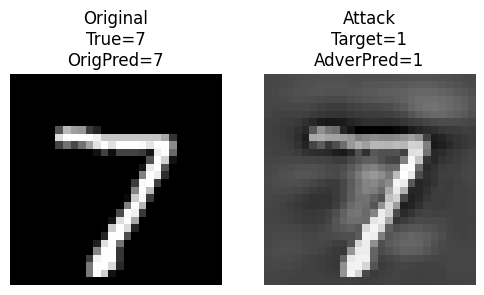

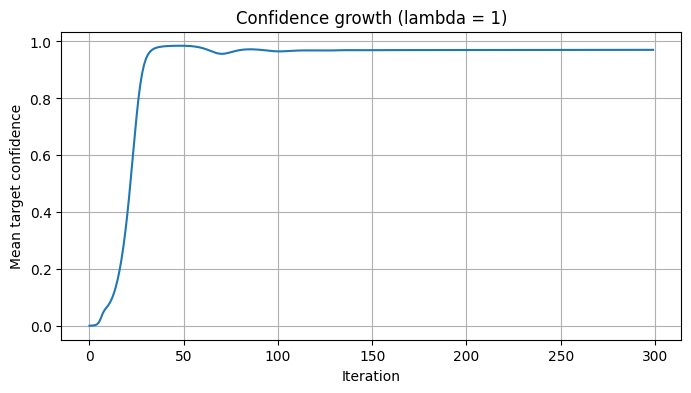

tensor([1], device='cuda:0')
torch.Size([1, 10])
lambda= 10
delta.shape: torch.Size([1, 1, 28, 28])
iteration: 0 loss: 6.359677314758301 mean confidence: 0.0017299249302595854
iteration: 25 loss: 2.0960094928741455 mean confidence: 0.6369121670722961
iteration: 50 loss: 1.6214895248413086 mean confidence: 0.8038949370384216
iteration: 75 loss: 1.5858925580978394 mean confidence: 0.8092690706253052
iteration: 100 loss: 1.5826313495635986 mean confidence: 0.8109055757522583
iteration: 125 loss: 1.582436203956604 mean confidence: 0.8111212849617004
iteration: 150 loss: 1.5824207067489624 mean confidence: 0.8112334609031677
iteration: 175 loss: 1.582419514656067 mean confidence: 0.8110578060150146
iteration: 200 loss: 1.582419514656067 mean confidence: 0.8110490441322327
iteration: 225 loss: 1.5824193954467773 mean confidence: 0.8110568523406982
iteration: 250 loss: 1.5824190378189087 mean confidence: 0.811057448387146
iteration: 275 loss: 1.5824196338653564 mean confidence: 0.811056733131

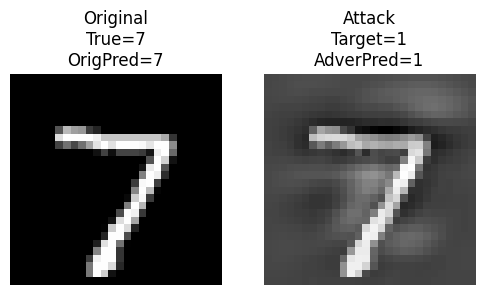

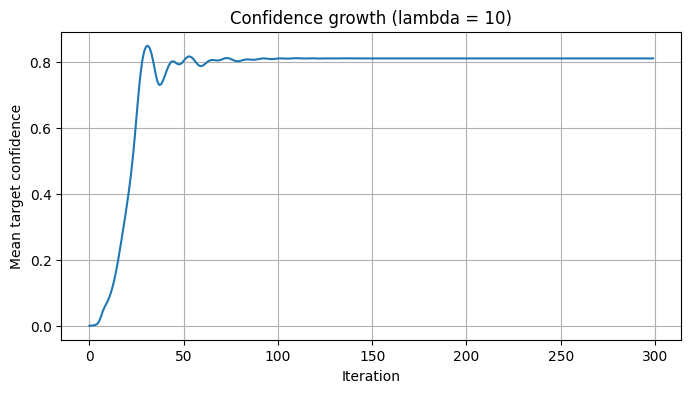

tensor([1], device='cuda:0')
torch.Size([1, 10])


In [ ]:
"""
exemplary code for number 7 recognized as 1
"""

import torch
import torchvision

testset = torchvision.datasets.MNIST(root='./data',
                                      train=False,
                                      download=True,
                                      transform=transform)

image, label = testset[0]
print("image.shape:", image.shape)
print("label:", label)

# input as batch
image = image.unsqueeze(0).to(device)
print("image.shape:", image.shape)

""""""
net.eval() # LeNet-5 without training behaviors

for param in net.parameters():
  param.requires_grad = False # without weights' training

target_wrong_class = torch.tensor([1]).to(device)


lambda_values = [0, 0.01, 0.1, 1, 10]
for lambda_l2 in lambda_values:
  print("lambda=", lambda_l2)

  # delta
  delta = torch.zeros_like(image, requires_grad=True)
  print("delta.shape:", delta.shape)

  dream_optimizer = torch.optim.Adam([delta], lr=0.05) # updates input images

  iterations = 300
  confidence_history = []

  for iteration in range(iterations):
    dream_optimizer.zero_grad() # reset gradient from previous iteration

    outputs = net(image + delta) # pass images

    ce_loss = F.cross_entropy(outputs, target_wrong_class) # cross-entropy loss, digit named by their digit
    l2 = delta.pow(2).mean()

    loss = ce_loss + lambda_l2 * l2 # total loss

    loss.backward() # gradients
    dream_optimizer.step() # update images using gradients

    probabilities = torch.softmax(outputs, dim=1)
    target_confidence = probabilities[0, target_wrong_class.item()] # confidence of given class


    confidence_history.append(target_confidence.item()) # save confidence for later visualisation


    if iteration % 25 == 0:
      print(
          "iteration:", iteration,
          "loss:", loss.item(),
          "mean confidence:", target_confidence.mean().item()
      )
  # prediction
  with torch.no_grad():
    original_prediction = net(image).argmax(dim=1).item()
    adversarial_prediction = net(image + delta).argmax(dim=1).item()


  # plotting
  images = (image + delta).detach().cpu() # moves tensor to cpu

  figure, axes = pyplot.subplots(1, 2, figsize=(6, 3))

  axes[0].imshow(image.cpu()[0, 0], cmap="gray")
  axes[0].set_title(
      f"Original\nTrue={label}\nOrigPred={original_prediction}"
  )

  axes[1].imshow((image + delta).detach().cpu()[0, 0], cmap="gray")
  axes[1].set_title(
      f"Attack\nTarget={target_wrong_class.item()}\nAdverPred={adversarial_prediction}"
  )

  for ax in axes:
      ax.axis("off")

  pyplot.show()


  """ confidence growth during optimization """
  pyplot.figure(figsize=(8, 4))
  pyplot.plot(confidence_history)
  pyplot.title(f"Confidence growth (lambda = {lambda_l2})")
  pyplot.xlabel("Iteration")
  pyplot.ylabel("Mean target confidence")
  pyplot.grid()
  pyplot.show()

  print(target_wrong_class)
  print(outputs.shape)




For this sample, all the attacks were successfull. For all counted values, successful rate was lower than 100% only for the highest lambda value.

For low lambda values, the penalty for the image perturbation (delta) is small, so the optimizer changes the image more freely until it is highly confident in the target class. The attack is very successful but image is less recognizable for human eye.

Larger lambda values give output more readable for human eye. It is still successful, but with less confidence rate due to stronger regularization. Delta value as a perturbation rate gets smaller when the lambda increases - perturbation is penalized by the loss function.